# Hit classifier + arrival-time flow testing

Validation for the two models that, together with the light-yield flow, make up the
hurdle description of a PMT response:

| model | quantity |
|---|---|
| `HitClassifier` | `pi(c) = P(PMT sees any light \| theta, x)` |
| `FlowMatchATime` | `p(t_res \| theta, x)` for photons that did arrive |

**Part A** tests the classifier, **Part B** the arrival-time flow, **Part C** puts them
together and simulates a whole event.

A note that governs Part A throughout: at ~0.011% occupancy, **accuracy is a useless
metric** — always predicting "never hit" scores 99.99%. Judge the classifier by
calibration and AUC instead.

## Setup

In [2]:
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'

import torch
import numpy as np
import matplotlib.pyplot as plt
import importlib
import pickle
import pandas as pd
import nugget
from scipy import stats

importlib.reload(nugget.surrogates.HitClassifier)
importlib.reload(nugget.surrogates.FlowMatchATime)
importlib.reload(nugget.surrogates.FlowMatchLY)
from nugget.surrogates.HitClassifier import HitClassifier, HitLabelDataset
from nugget.surrogates.FlowMatchATime import FlowMatchATime, ArrivalTimeFlowDataset
from nugget.surrogates.FlowMatchLY import FlowMatchLY

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


In [ ]:
device = 'cuda:1' if torch.cuda.is_available() else 'cpu'
GEOM = '../other/800_40_40_geom.csv'

HIT_CKPT    = './flow_models/best_mc_hit_model_v4.pt'
HIT_TEST    = './flow_models/mc_hit_v4_test_samples.parquet'
HIT_HIST    = './flow_models/mc_hit_v4_training_history.pkl'

ATIME_CKPT  = './flow_models/best_mc_atime_muon_flow_model_v5.pt'
ATIME_TEST  = './flow_models/mc_atime_muon_flow_v5_test_samples.parquet'
ATIME_HIST  = './flow_models/mc_atime_muon_flow_v5_training_history.pkl'

LY_CKPT     = './flow_models/best_mc_ly_muon_flow_model_v2.pt'   # for Part C

N_STEPS = 64      # ODE steps for the arrival-time flow
N_EVAL  = 100_000 # samples for the classifier tests
N_EVAL_T = 200_000 # photons for the flow tests

hit = HitClassifier(device=device, domain_size=8000)
hit.load_model(HIT_CKPT)
hit.net.eval()
print(f'hit classifier : context_dim={hit.context_dim}, '
      f'log_prior_odds={hit.log_prior_odds:.4f}')

flow = FlowMatchATime(device=device, domain_size=8000)
flow.load_model(ATIME_CKPT)
flow.net.eval()
print(f'arrival-time flow: context_dim={flow.context_dim}, n={flow.refractive_index}, '
      f'transform={flow.time_transform}(t/{flow.time_scale:g})')
print(f'  target transform mu={flow.target_mu:.4f} sigma={flow.target_sigma:.4f}')

# light-yield flow: only needed for the joint simulation in Part C
ly = FlowMatchLY(device=device, domain_size=8000)
ly.load_model(LY_CKPT)
ly.net.eval()
print(f'light-yield flow : context_dim={ly.context_dim}')

# assert hit.context_dim == flow.context_dim == ly.context_dim, (
#     'all three models must share the same context layout for Part C')

OSError: [Errno 5] Input/output error

---
# Part A — hit classifier

In [3]:
ds_hit = HitLabelDataset(
    hit, parquet_path=HIT_TEST, geometry_csv_path=GEOM,
    num_samples_per_epoch=N_EVAL, seed=None, pos_frac=0.5,
    uniform_energy_zenith=False,      # natural event distribution for testing
    filter_vertex_in_domain=True,
)
ctx_h, y_h = ds_hit.get_batch(range(N_EVAL))
ctx_h = ctx_h.to(device)
y_np = y_h.numpy()
print(f'{N_EVAL:,} balanced samples, positive fraction {y_np.mean():.3f}')

HitLabelDataset: dropped 140,425 row(s) with muon vertex outside [5000.0, 5000.0, 5000.0]
HitLabelDataset: 4,818,624 hits, 47,968 events, 903,968 PMTs
  43,361,537,024 (event, PMT) cells -> occupancy P(hit) = 0.000111127 (0.0111%)
  training at pos_frac=0.5; calibrated logits need a shift of log_prior_odds = -9.1047
100,000 balanced samples, positive fraction 0.500


### A1 — training history

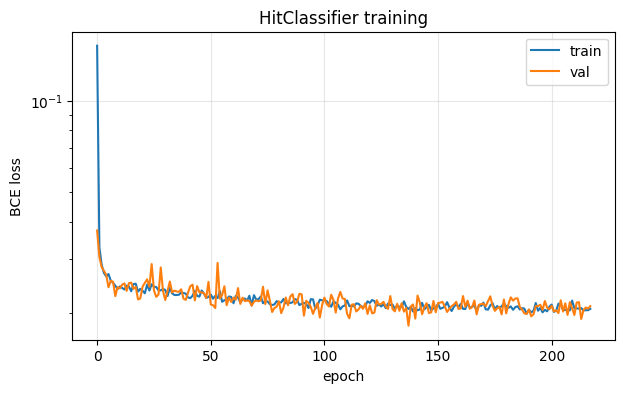

best val: 0.01813297681886871


In [4]:
hist = pickle.load(open(HIT_HIST, 'rb'))
plt.figure(figsize=(7, 4))
plt.plot(hist['train_loss'], label='train')
if hist.get('val_loss'):
    plt.plot(hist['val_loss'], label='val')
plt.xlabel('epoch'); plt.ylabel('BCE loss'); plt.yscale('log')
plt.legend(); plt.grid(alpha=.3); plt.title('HitClassifier training'); plt.show()
print('best val:', min(hist['val_loss']) if hist.get('val_loss') else 'n/a')

### A2 — calibration on the balanced sample

`calibrated=False` here, because this sample is 50/50 by construction and the
calibrated output would (correctly) report the far smaller natural occupancy.
Points should sit on the diagonal.

   mean pred   empirical         n
      0.0000      0.0000      6667
      0.0000      0.0000      6667
      0.0000      0.0000      6666
      0.0000      0.0000      6667
      0.0000      0.0000      6666
      0.0000      0.0000      6667
      0.0000      0.0000      6667
      0.5338      0.5140      6666
      0.9906      0.9910      6667
      0.9968      0.9976      6666
      0.9985      0.9990      6667
      0.9992      0.9993      6667
      0.9995      0.9995      6666
      0.9997      0.9999      6667
      0.9999      0.9999      6667

expected calibration error (ECE) = 0.00146


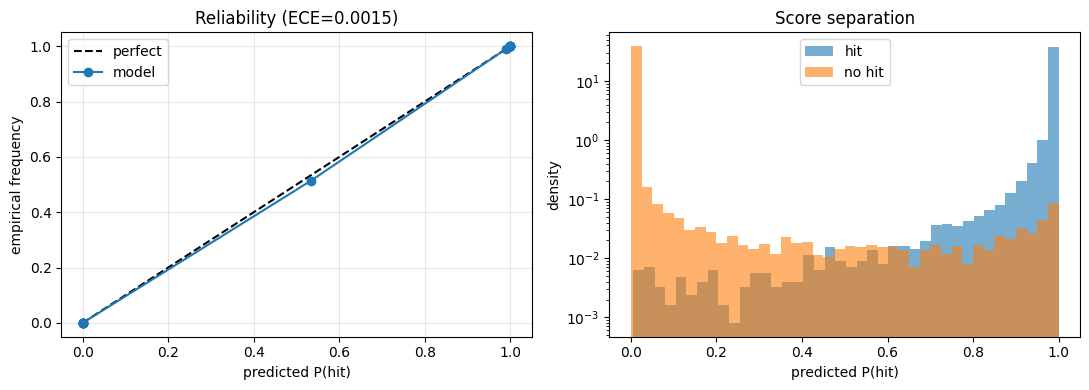

In [5]:
rows = hit.reliability(ctx_h, y_h, n_bins=15, calibrated=False)
pred = np.array([r[0] for r in rows]); emp = np.array([r[1] for r in rows])
cnt  = np.array([r[2] for r in rows])

print(f'  {"mean pred":>10}  {"empirical":>10}  {"n":>8}')
for p, e, n in rows:
    print(f'  {p:10.4f}  {e:10.4f}  {n:8d}')

p_unc = hit.predict_hit_prob(ctx_h, calibrated=False).detach().cpu().numpy()
ece = np.sum(cnt / cnt.sum() * np.abs(pred - emp))
print(f'\nexpected calibration error (ECE) = {ece:.5f}')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot([0, 1], [0, 1], 'k--', label='perfect')
ax[0].plot(pred, emp, 'o-', label='model')
ax[0].set_xlabel('predicted P(hit)'); ax[0].set_ylabel('empirical frequency')
ax[0].set_title(f'Reliability (ECE={ece:.4f})'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].hist(p_unc[y_np == 1], bins=40, alpha=.6, label='hit', density=True)
ax[1].hist(p_unc[y_np == 0], bins=40, alpha=.6, label='no hit', density=True)
ax[1].set_xlabel('predicted P(hit)'); ax[1].set_ylabel('density')
ax[1].set_yscale('log'); ax[1].set_title('Score separation'); ax[1].legend()
plt.tight_layout(); plt.show()

### A3 — ROC and precision–recall

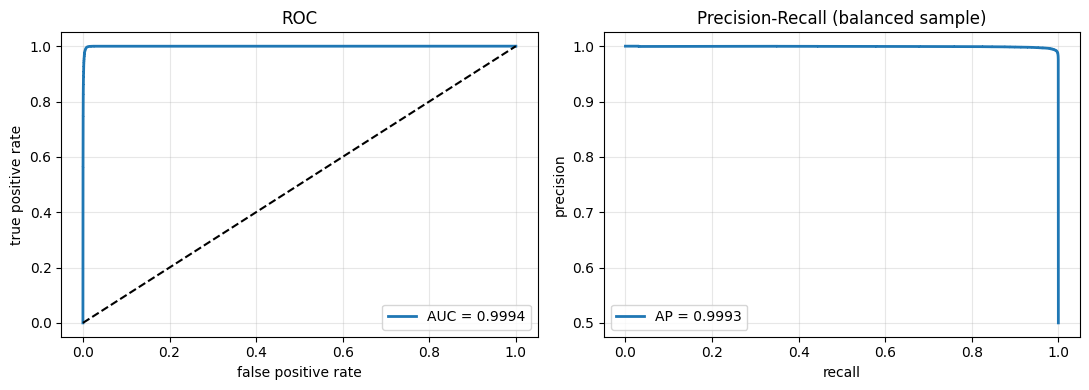

ROC AUC = 0.9994   AP = 0.9993
NB: PR is computed on the BALANCED sample; on natural data the baseline precision would be the occupancy, 1.11e-04.


In [6]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

fpr, tpr, _ = roc_curve(y_np, p_unc)
roc_auc = auc(fpr, tpr)
prec, rec, _ = precision_recall_curve(y_np, p_unc)
ap = average_precision_score(y_np, p_unc)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.4f}')
ax[0].plot([0, 1], [0, 1], 'k--')
ax[0].set_xlabel('false positive rate'); ax[0].set_ylabel('true positive rate')
ax[0].set_title('ROC'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(rec, prec, lw=2, label=f'AP = {ap:.4f}')
ax[1].set_xlabel('recall'); ax[1].set_ylabel('precision')
ax[1].set_title('Precision-Recall (balanced sample)'); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()
print(f'ROC AUC = {roc_auc:.4f}   AP = {ap:.4f}')
print('NB: PR is computed on the BALANCED sample; on natural data the baseline '
      f'precision would be the occupancy, {ds_hit.p_hit:.2e}.')

### A4 — does the prior correction recover the true occupancy?

The decisive test of `log_prior_odds`. Draw `(event, PMT)` pairs uniformly — i.e. from
the *natural* distribution, not the balanced one — and average the calibrated
probability. It should reproduce the measured occupancy.

In [7]:
rng = np.random.default_rng()
M = 400_000
ev = ds_hit._sample_events(M)
gi = rng.integers(0, ds_hit._n_geo, size=M)
ctx_nat = hit.build_context(
    torch.from_numpy(ds_hit._geo_pos[gi]),
    torch.from_numpy(ds_hit._ev_vertex[ev]),
    torch.from_numpy(ds_hit._ev_energy[ev]),
    torch.from_numpy(ds_hit._ev_zenith[ev]),
    torch.from_numpy(ds_hit._ev_azimuth[ev]),
    torch.from_numpy(ds_hit._geo_dir[gi]),
).to(device)
p_nat = hit.predict_hit_prob(ctx_nat, calibrated=True).detach().cpu().numpy()
truth_nat = ds_hit._is_hit(ev, gi).mean()

print(f'calibrated  mean P(hit) over natural sample = {p_nat.mean():.6g}')
print(f'empirical   hit rate in the same sample     = {truth_nat:.6g}')
print(f'dataset-wide occupancy                      = {ds_hit.p_hit:.6g}')
print(f'\nratio model/dataset = {p_nat.mean()/ds_hit.p_hit:.3f}   (1.0 = calibrated)')
print(f'log_prior_odds applied = {hit.log_prior_odds:.4f}')

calibrated  mean P(hit) over natural sample = 0.000101773
empirical   hit rate in the same sample     = 0.0001175
dataset-wide occupancy                      = 0.000111127

ratio model/dataset = 0.916   (1.0 = calibrated)
log_prior_odds applied = -9.0995


### A5 — does P(hit) follow the physics?

Calibrated hit probability against perpendicular distance to the track and against
energy, compared with the empirical hit rate in the same bins.

    multiplicity  n_events  P(hit) data       model   ratio
     1-2              2437    1.106e-06   9.161e-06    8.28
     2-4              1943    2.675e-06   1.189e-05    4.45
     4-9              2672    6.454e-06   1.715e-05    2.66
     9-19             5371    1.511e-05   2.082e-05    1.38
    19-39            10821    3.114e-05   3.238e-05    1.04
    39-82            11365    6.226e-05   5.520e-05    0.89
    82-172            7744    1.302e-04   1.173e-04    0.90
   172-358            3364    2.626e-04   2.573e-04    0.98
   358-746            1320    5.549e-04   4.997e-04    0.90
   746-1556            629    1.174e-03   1.056e-03    0.90
  1556-3245            258    2.382e-03   1.585e-03    0.67
  3245-6768             44    4.600e-03   1.835e-03    0.40
data spans 4158x, model spans 200x


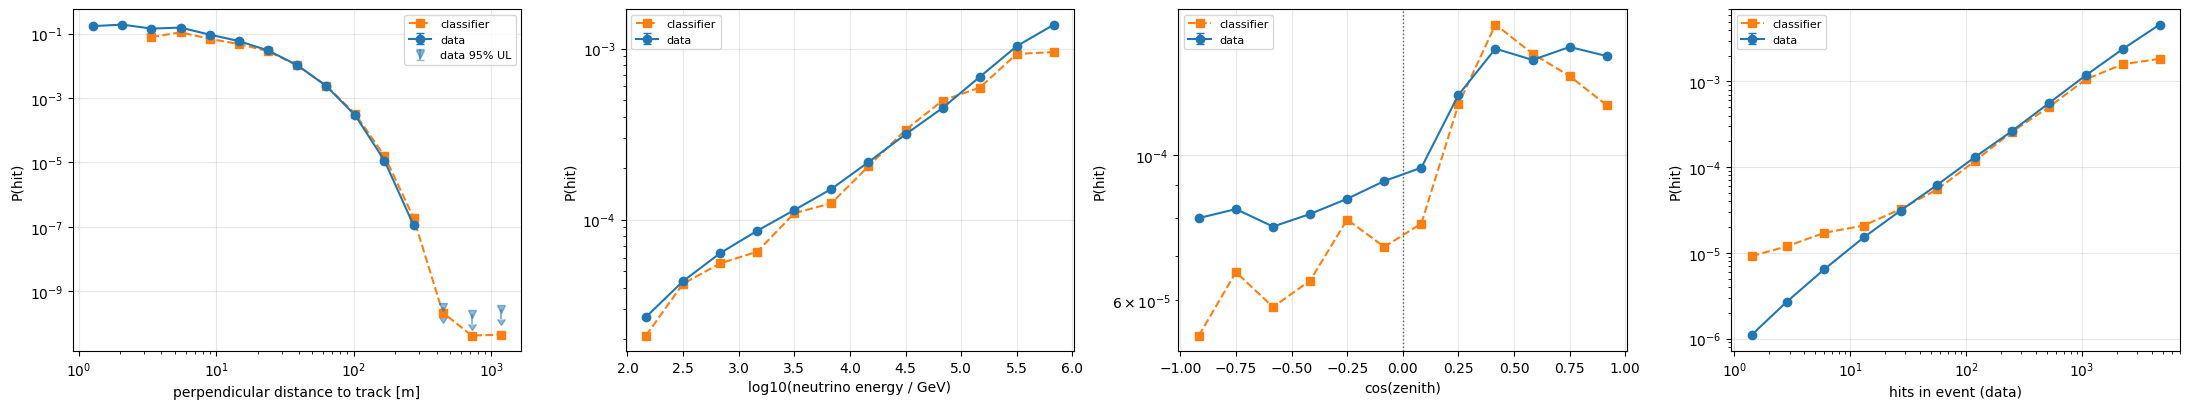

 cos(zen)   n_hits  n_events  P(hit) data       model   ratio
    -0.92   259261      3580    8.011e-05   5.286e-05    0.66
    -0.75   272459      3645    8.269e-05   6.616e-05    0.80
    -0.58   256318      3648    7.773e-05   5.847e-05    0.75
    -0.42   269322      3666    8.127e-05   6.421e-05    0.79
    -0.25   278637      3594    8.576e-05   7.967e-05    0.93
    -0.08   288007      3489    9.132e-05   7.236e-05    0.79
     0.08   313846      3627    9.572e-05   7.856e-05    0.82
     0.25   438849      3921    1.238e-04   1.197e-04    0.97
     0.42   593379      4500    1.459e-04   1.588e-04    1.09
     0.58   608622      4804    1.401e-04   1.433e-04    1.02
     0.75   645047      4863    1.467e-04   1.324e-04    0.90
     0.92   594877      4631    1.421e-04   1.194e-04    0.84


In [8]:
# P(hit) trends, estimated with the FULL hit sample as the numerator.
# (Sampling cells and counting hits, as in A4, yields ~42 hits total and cannot
#  resolve anything below ~3e-5 -- every far bin reads exactly 0.)
M_CELL, M_MODEL = 2_000_000, 2000_000
rng5 = np.random.default_rng()

def perp_of(ev_, gi_):
    u = np.stack([np.sin(ds_hit._ev_zenith[ev_]) * np.cos(ds_hit._ev_azimuth[ev_]),
                  np.sin(ds_hit._ev_zenith[ev_]) * np.sin(ds_hit._ev_azimuth[ev_]),
                  np.cos(ds_hit._ev_zenith[ev_])], 1)
    rel = ds_hit._geo_pos[gi_] - ds_hit._ev_vertex[ev_]
    return np.linalg.norm(rel - (rel * u).sum(1)[:, None] * u, axis=1)

def model_p(ev_, gi_, batch=65536):
    out = np.empty(len(ev_))
    for s in range(0, len(ev_), batch):
        e = min(s + batch, len(ev_))
        c = hit.build_context(
            torch.from_numpy(ds_hit._geo_pos[gi_[s:e]]),
            torch.from_numpy(ds_hit._ev_vertex[ev_[s:e]]),
            torch.from_numpy(ds_hit._ev_energy[ev_[s:e]]),
            torch.from_numpy(ds_hit._ev_zenith[ev_[s:e]]),
            torch.from_numpy(ds_hit._ev_azimuth[ev_[s:e]]),
            torch.from_numpy(ds_hit._geo_dir[gi_[s:e]])).to(device)
        out[s:e] = hit.predict_hit_prob(c, calibrated=True).detach().cpu().numpy()
    return out

cells_total = ds_hit._n_events * ds_hit._n_geo
ev_h, gi_h = ds_hit._hit_key // ds_hit._n_geo, ds_hit._hit_key % ds_hit._n_geo
ev_c = ds_hit._sample_events(M_CELL)
gi_c = rng5.integers(0, ds_hit._n_geo, size=M_CELL)
pm = model_p(ev_c[:M_MODEL], gi_c[:M_MODEL])

fig, ax = plt.subplots(1, 4, figsize=(22, 4.2))

# --- (a) perpendicular distance: denominator estimated from sampled cells ---
perp_h, perp_c = perp_of(ev_h, gi_h), perp_of(ev_c, gi_c)
edges = np.logspace(np.log10(max(perp_h.min(), 1.0)), np.log10(1500), 16)
nh, _ = np.histogram(perp_h, bins=edges)
nc, _ = np.histogram(perp_c, bins=edges)
cells = nc * (cells_total / M_CELL)
ctr = np.sqrt(edges[:-1] * edges[1:])
rate = np.where(nc > 0, nh / np.maximum(cells, 1e-30), np.nan)
err  = np.where(nh > 0, rate / np.sqrt(np.maximum(nh, 1)), np.nan)
ib = np.clip(np.digitize(perp_c[:M_MODEL], edges) - 1, 0, len(nh) - 1)
mod = np.array([pm[ib == b].mean() if (ib == b).sum() > 20 else np.nan
                for b in range(len(nh))])
meas = (nc > 0) & (nh > 0)
ax[0].errorbar(ctr[meas], rate[meas], yerr=err[meas], fmt='o-', capsize=3, label='data')
zero = (nc > 0) & (nh == 0)          # 0 hits -> 95% upper limit, not "P = 0"
if zero.any():
    ul = 3.0 / np.maximum(cells[zero], 1e-30)
    ax[0].errorbar(ctr[zero], ul, yerr=ul * .5, uplims=True, fmt='v', color='C0',
                   alpha=.5, label='data 95% UL')
ax[0].plot(ctr, mod, 's--', color='C1', label='classifier')
ax[0].set_xscale('log')
ax[0].set_xlabel('perpendicular distance to track [m]')

# --- (b, c) per-EVENT quantities: denominator is EXACT (n_events x n_geo) ---
def per_event_panel(a, val_ev, edges_, xlabel):
    nh_, _  = np.histogram(val_ev[ev_h], bins=edges_)
    nev_, _ = np.histogram(val_ev, bins=edges_)
    ok_ = (nev_ > 0) & (nh_ > 0)
    r_ = np.where(ok_, nh_ / np.maximum(nev_ * ds_hit._n_geo, 1e-30), np.nan)
    e_ = np.where(ok_, r_ / np.sqrt(np.maximum(nh_, 1)), np.nan)
    c_ = .5 * (edges_[:-1] + edges_[1:])
    ib_ = np.clip(np.digitize(val_ev[ev_c[:M_MODEL]], edges_) - 1, 0, len(nh_) - 1)
    m_ = np.array([pm[ib_ == b].mean() if (ib_ == b).sum() > 20 else np.nan
                   for b in range(len(nh_))])
    a.errorbar(c_[ok_], r_[ok_], yerr=e_[ok_], fmt='o-', capsize=3, label='data')
    a.plot(c_, m_, 's--', color='C1', label='classifier')
    a.set_xlabel(xlabel)
    return c_, r_, m_, nh_, nev_

logE_ev = np.log10(ds_hit._ev_energy)
per_event_panel(ax[1], logE_ev, np.linspace(logE_ev.min(), logE_ev.max(), 13),
                'log10(neutrino energy / GeV)')

cz_ev = np.cos(ds_hit._ev_zenith)
cz_c, cz_r, cz_m, cz_nh, cz_nev = per_event_panel(
    ax[2], cz_ev, np.linspace(-1, 1, 13), 'cos(zenith)')

# --- (d) P(hit) vs event hit-multiplicity -------------------------------------
# Denominator is exact: an event with m hits has P(hit) = m / n_geo by definition,
# so the data curve is a straight line and any deviation is purely model error.
mult = np.bincount(ev_h, minlength=ds_hit._n_events).astype(np.float64)
m_edges = np.unique(np.round(np.logspace(0, np.log10(mult.max() + 1), 13)).astype(int))
nev_m, _ = np.histogram(mult, bins=m_edges)
nh_m, _  = np.histogram(mult, bins=m_edges, weights=mult)
ok_m  = (nev_m > 0) & (nh_m > 0)
r_m   = np.where(ok_m, nh_m / np.maximum(nev_m * ds_hit._n_geo, 1e-30), np.nan)
e_m   = np.where(ok_m, r_m / np.sqrt(np.maximum(nh_m, 1)), np.nan)
c_m   = np.sqrt(m_edges[:-1].astype(float) * m_edges[1:])

ib_m  = np.clip(np.digitize(mult[ev_c[:M_MODEL]], m_edges) - 1, 0, len(nev_m) - 1)
mod_m = np.array([pm[ib_m == b].mean() if (ib_m == b).sum() > 200 else np.nan
                  for b in range(len(nev_m))])

ax[3].errorbar(c_m[ok_m], r_m[ok_m], yerr=e_m[ok_m], fmt='o-', capsize=3, label='data')
ax[3].plot(c_m, mod_m, 's--', color='C1', label='classifier')
ax[3].set_xscale('log')
ax[3].set_xlabel('hits in event (data)')

print(f'{"multiplicity":>16} {"n_events":>9} {"P(hit) data":>12} {"model":>11} {"ratio":>7}')
for i in range(len(nev_m)):
    if not ok_m[i] or not np.isfinite(mod_m[i]): continue
    print(f'{m_edges[i]:6d}-{m_edges[i+1]:<9d} {nev_m[i]:>9d} {r_m[i]:>12.3e} '
          f'{mod_m[i]:>11.3e} {mod_m[i]/r_m[i]:>7.2f}')
f_ = np.isfinite(mod_m) & np.isfinite(r_m)
print(f'data spans {np.nanmax(r_m[f_])/np.nanmin(r_m[f_]):.0f}x, '
      f'model spans {np.nanmax(mod_m[f_])/np.nanmin(mod_m[f_]):.0f}x')

for a in ax:
    a.set_yscale('log'); a.set_ylabel('P(hit)'); a.legend(fontsize=8); a.grid(alpha=.3)
ax[2].axvline(0, color='k', ls=':', lw=1, alpha=.6)   # horizon
plt.tight_layout(); plt.show()

print(f'{"cos(zen)":>9} {"n_hits":>8} {"n_events":>9} {"P(hit) data":>12} {"model":>11} {"ratio":>7}')
for i in range(len(cz_nh)):
    if cz_nev[i] == 0: continue
    rr = cz_m[i] / cz_r[i] if np.isfinite(cz_r[i]) and cz_r[i] > 0 else np.nan
    print(f'{cz_c[i]:>9.2f} {cz_nh[i]:>8d} {cz_nev[i]:>9d} {cz_r[i]:>12.3e} '
          f'{cz_m[i]:>11.3e} {rr:>7.2f}')


### A6 — joint distribution of the hit population

A1–A5 each test one marginal at a time. This compares the **joint**: for the same
events, is the set of PMTs the classifier lights up distributed like the set the data
lights up?

The model side is every cell within `D_MAX` of the track weighted by its calibrated
`P(hit)` — the classifier's exact hit distribution, with no Bernoulli sampling noise.
Two printed numbers matter: the fraction of data hits *beyond* `D_MAX` (should be ~0,
or raise it) and the ESS of the weights (raise `N_CORNER_EVENTS` if it is small).

Event-level variables (energy, zenith, azimuth) take one value per event, so those
panels show `N_CORNER_EVENTS` discrete stripes rather than a smooth density — there the
comparison is of the *spread within each stripe*. The per-PMT panels (`d_perp`,
`d_long`, `P(hit)`) are informative even with few events.

Set `CORNER_VARS_HIT` to any subset of the keys built in `_row` — `'d_long [m]'` and
`'log10(d_vertex/m)'` are also available.

100 events | data hits 8,902 (0.00% beyond D_MAX -- raise it if not ~0)
model: expected 8315 hits over 4,509,090 weighted cells, ESS = 48932


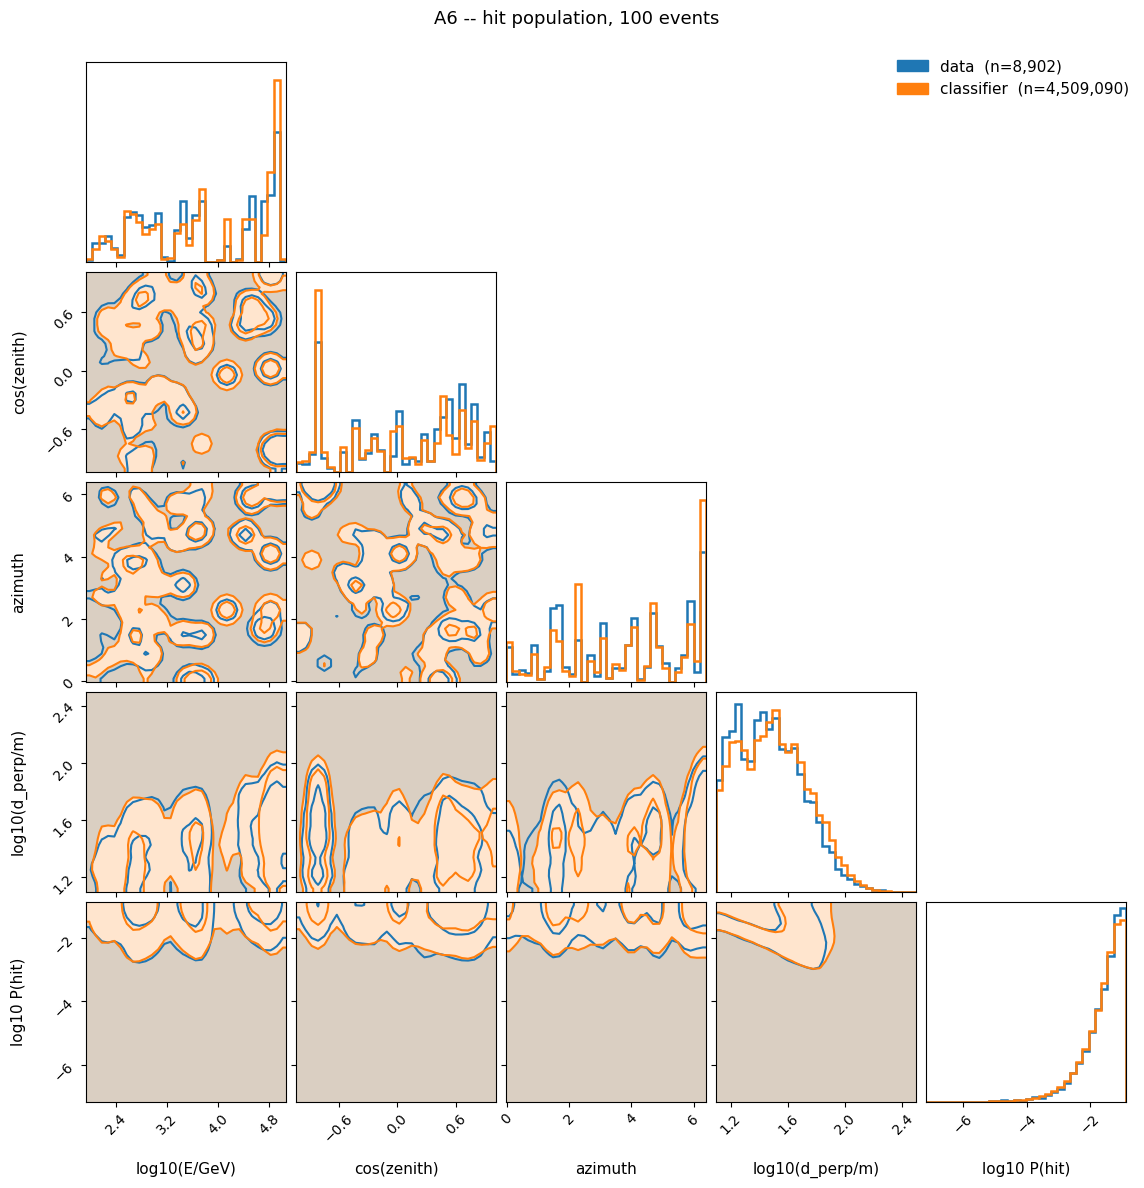

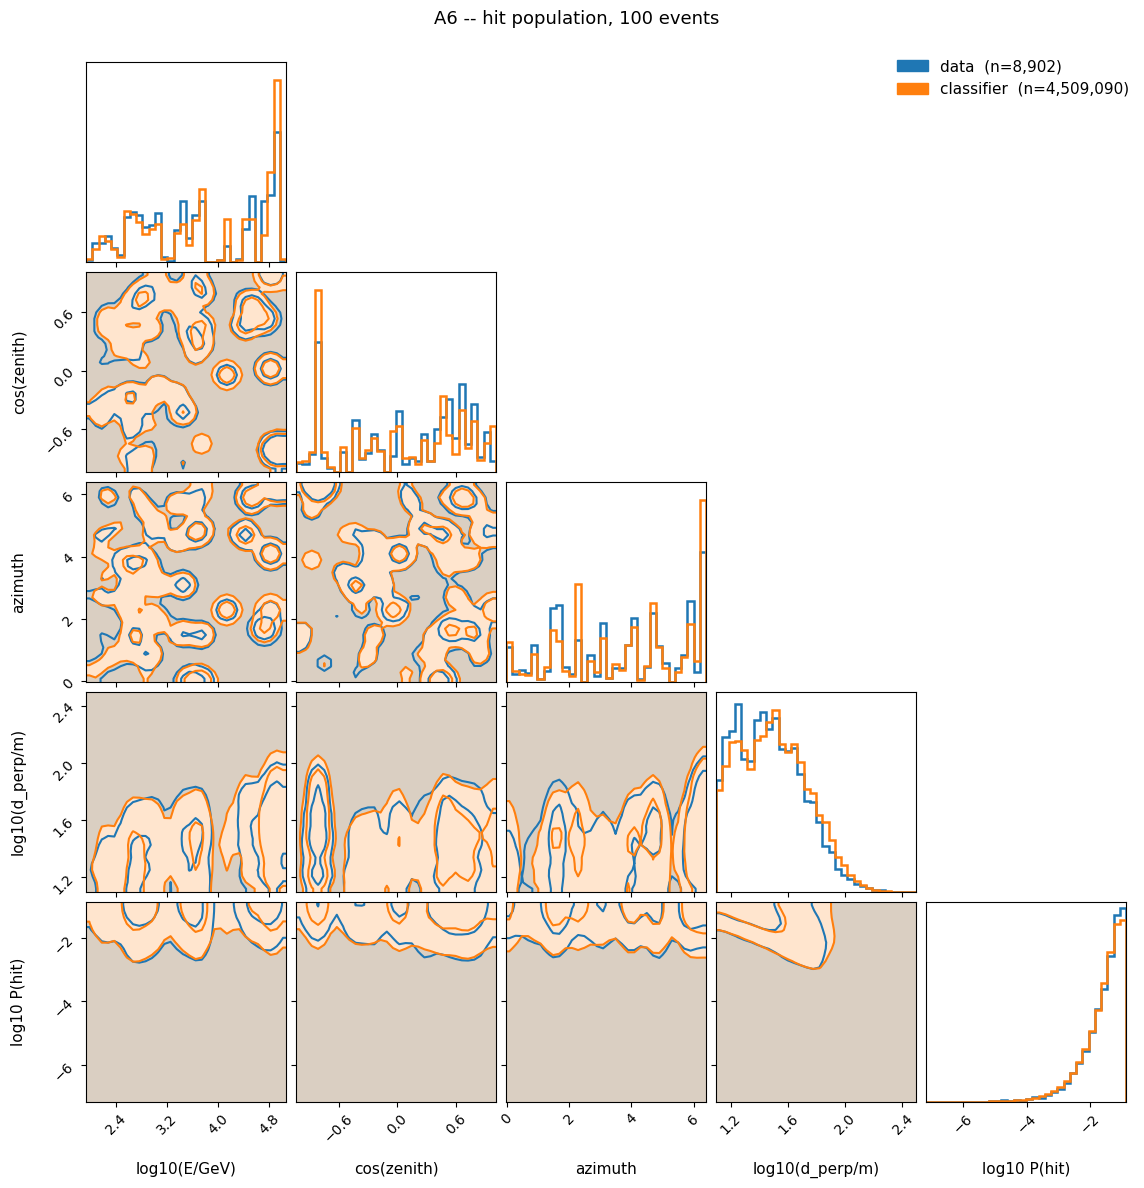

In [9]:
# --- A6 -- joint distribution of the HIT POPULATION, data vs classifier ------
# A1-A5 test one marginal at a time. This compares the full joint: for the same
# events, does the set of PMTs the classifier lights up look like the set the
# data lights up? The model side is every cell weighted by P(hit), which is the
# classifier's exact hit distribution (no Bernoulli sampling noise).
N_CORNER_EVENTS = 100         # cost is ~N x (PMTs within D_MAX) forward passes
D_MAX  = 300.0                # m; skip the net where P(hit) is negligible
P_KEEP = 1e-7                 # drop cells too improbable to carry weight

# pick any subset of the keys built below
CORNER_VARS_HIT = ['log10(E/GeV)', 'cos(zenith)', 'azimuth',
                   'log10(d_perp/m)', 'log10 P(hit)']

rng_c = np.random.default_rng(0)
ev_sel = rng_c.choice(ds_hit._n_events, size=N_CORNER_EVENTS, replace=False)


def _track_frame(ev_i, pos):
    """(d_perp, d_long, d_vertex) of PMT positions w.r.t. event ev_i's track."""
    z, a = float(ds_hit._ev_zenith[ev_i]), float(ds_hit._ev_azimuth[ev_i])
    d = np.array([np.sin(z) * np.cos(a), np.sin(z) * np.sin(a), np.cos(z)])
    u = -d if getattr(hit, 'track_dir_is_arrival', False) else d
    rel = pos.astype(np.float64) - ds_hit._ev_vertex[ev_i].astype(np.float64)
    dl = rel @ u
    return np.linalg.norm(rel - dl[:, None] * u, axis=1), dl, np.linalg.norm(rel, axis=1)


def _p_hit(ev_i, gi, batch=65536):
    out = np.empty(len(gi), np.float64)
    for s in range(0, len(gi), batch):
        e = min(s + batch, len(gi))
        b = e - s
        c = hit.build_context(
            torch.from_numpy(ds_hit._geo_pos[gi[s:e]]),
            torch.from_numpy(np.tile(ds_hit._ev_vertex[ev_i], (b, 1))),
            torch.from_numpy(np.full(b, ds_hit._ev_energy[ev_i], np.float32)),
            torch.from_numpy(np.full(b, ds_hit._ev_zenith[ev_i], np.float32)),
            torch.from_numpy(np.full(b, ds_hit._ev_azimuth[ev_i], np.float32)),
            torch.from_numpy(ds_hit._geo_dir[gi[s:e]])).to(device)
        out[s:e] = hit.predict_hit_prob(c, calibrated=True).detach().cpu().numpy()
    return out


def _row(ev_i, gi, p):
    dp, dl, dv = _track_frame(ev_i, ds_hit._geo_pos[gi])
    n = len(gi)
    return {
        'log10(E/GeV)':      np.full(n, np.log10(max(ds_hit._ev_energy[ev_i], 1e-12))),
        'cos(zenith)':       np.full(n, np.cos(ds_hit._ev_zenith[ev_i])),
        'azimuth':           np.full(n, ds_hit._ev_azimuth[ev_i]),
        'log10(d_perp/m)':   np.log10(np.maximum(dp, 1e-2)),
        'd_long [m]':        dl,
        'log10(d_vertex/m)': np.log10(np.maximum(dv, 1e-2)),
        'log10 P(hit)':      np.log10(np.maximum(p, 1e-30)),
    }


acc_d, acc_m, w_m = [], [], []
n_beyond = n_data = 0
for k, ev_i in enumerate(ev_sel):
    # ---- data: this event's real hits ----
    lo = np.searchsorted(ds_hit._hit_key, ev_i * ds_hit._n_geo)
    hi_ = np.searchsorted(ds_hit._hit_key, (ev_i + 1) * ds_hit._n_geo)
    gi_d = (ds_hit._hit_key[lo:hi_] - ev_i * ds_hit._n_geo).astype(np.int64)
    if len(gi_d) == 0:
        continue
    dp_d, _, _ = _track_frame(ev_i, ds_hit._geo_pos[gi_d])
    n_data += len(gi_d)
    n_beyond += int((dp_d >= D_MAX).sum())
    acc_d.append(_row(ev_i, gi_d, _p_hit(ev_i, gi_d)))

    # ---- model: every cell inside D_MAX, weighted by P(hit) ----
    dp_a, _, _ = _track_frame(ev_i, ds_hit._geo_pos)
    gi_a = np.flatnonzero(dp_a < D_MAX).astype(np.int64)
    p_a = _p_hit(ev_i, gi_a)
    keep = p_a > P_KEEP
    acc_m.append(_row(ev_i, gi_a[keep], p_a[keep]))
    w_m.append(p_a[keep])
    if (k + 1) % 5 == 0:
        print(f'  {k + 1}/{len(ev_sel)} events', end='\r')

cat = lambda L: {kk: np.concatenate([d[kk] for d in L]) for kk in L[0]}
S_data, S_model = cat(acc_d), cat(acc_m)
W = np.concatenate(w_m)
ess = W.sum() ** 2 / (W ** 2).sum()
print(f'{len(ev_sel)} events | data hits {n_data:,} '
      f'({n_beyond / max(n_data, 1):.2%} beyond D_MAX -- raise it if not ~0)')
print(f'model: expected {W.sum():.0f} hits over {len(W):,} weighted cells, '
      f'ESS = {ess:.0f}')

nugget.utils.vis_tools.plot_corner_compare(
    {'data': S_data, 'classifier': S_model},
    variables=CORNER_VARS_HIT,
    weights={'data': None, 'classifier': W},
    bins=32, smooth=1.2,
    title=f'A6 -- hit population, {len(ev_sel)} events')

---
# Part B — arrival-time flow

The modelled quantity is the Cherenkov time residual

`t_res = t_hit - t_geom(theta, x)`

`t_geom` is the earliest direct-photon arrival time, so `t_res` isolates scattering
plus PMT jitter. Negative values are physical (jitter) and the transform is designed
to keep them.

In [20]:
ds_t = ArrivalTimeFlowDataset(
    flow, parquet_path=ATIME_TEST, geometry_csv_path=GEOM, uniform_energy_zenith=False, filter_vertex_in_domain=True, seed =None
)
ctx_t, t_true = ds_t.get_batch(range(N_EVAL_T))
ctx_t = ctx_t.to(device)
t_np = t_true.numpy().astype(np.float64)
print(f'{N_EVAL_T:,} photons | t_res: p1={np.percentile(t_np,1):.2f} '
      f'median={np.median(t_np):.2f} p99={np.percentile(t_np,99):.2f} '
      f'frac<0={np.mean(t_np<0):.4f}')

ArrivalTimeFlowDataset: 'times' layout = ragged list per row; 33,692,744 photons over 4,902,907 rows
ArrivalTimeFlowDataset: dropped 139,629 row(s) with muon vertex outside [5000.0, 5000.0, 5000.0]
ArrivalTimeFlowDataset: 4,763,278 rows (PMTs), 32,965,765 photons, 48,004 events, 32,965,765 samples/epoch
  photons/row: mean 6.92, median 1, max 168618
20,000 photons | t_res: p1=-28.75 median=4.08 p99=208.80 frac<0=0.0984


### B1 — training history

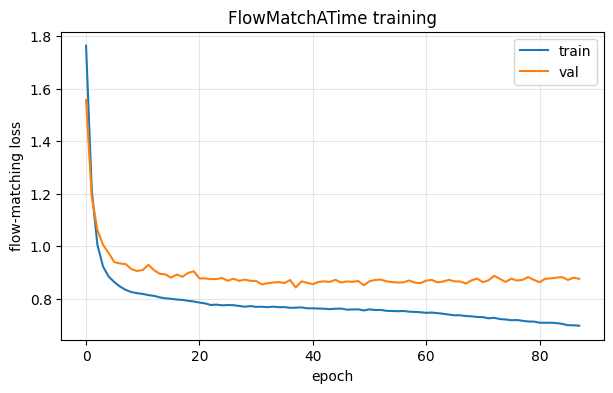

best val: 0.8429751015632163


In [22]:
hist_t = pickle.load(open(ATIME_HIST, 'rb'))
plt.figure(figsize=(7, 4))
plt.plot(hist_t['train_loss'], label='train')
if hist_t.get('val_loss'):
    plt.plot(hist_t['val_loss'], label='val')
plt.xlabel('epoch'); plt.ylabel('flow-matching loss'); plt.legend(); plt.grid(alpha=.3)
plt.title('FlowMatchATime training'); plt.show()
print('best val:', min(hist_t['val_loss']) if hist_t.get('val_loss') else 'n/a')

### B2 — density normalisation

`integral p(z|c) dz` must be 1. A sign error in the divergence accumulation still
produces plausible samples while corrupting every likelihood, so check this first.

In [23]:
zs = torch.linspace(-8, 8, 1601, device=device,
                    dtype=flow.param_dtype).reshape(-1, 1)
print('integral of p(z|c) dz  (should be 1.000)')
for k in range(5):
    cc = ctx_t[k:k+1].repeat(len(zs), 1)
    lp = flow.log_prob_z(zs, cc, n_steps=N_STEPS)
    print(f'  context {k}: {torch.trapezoid(lp.exp().double(), zs.reshape(-1).double()).item():.5f}')

integral of p(z|c) dz  (should be 1.000)


  context 0: 1.01665
  context 1: 1.01925
  context 2: 1.01221
  context 3: 1.01058
  context 4: 1.00980


### B3 — ODE step convergence

Unlike the light-yield model there is **no dequantisation** here (arrival times are
already continuous), so `log_prob_time_residual` is deterministic and this test
measures genuine ODE discretisation error. It should fall monotonically.

In [24]:
sub = ctx_t[:2000]
t_sub = t_true[:2000].to(device)
ref = flow.log_prob_time_residual(t_sub, sub, n_steps=256).double()
print('n_steps   mean|log p - log p(256 steps)|')
for n in [4, 8, 16, 32, 64, 128]:
    lp = flow.log_prob_time_residual(t_sub, sub, n_steps=n).double()
    print(f'  {n:4d}     {(lp - ref).abs().mean().item():.6f}')

n_steps   mean|log p - log p(256 steps)|
     4     0.347667
     8     0.184448
    16     0.092330
    32     0.047717
    64     0.023373
   128     0.006987


### B4 — marginal consistency of the time residual

data  p1=   -28.75 p25=    1.32 median=    4.08 p75=   11.22 p99=   208.80 frac<0=0.0984 max=885
flow  p1=   -35.50 p25=    1.67 median=    4.69 p75=   12.63 p99=   226.40 frac<0=0.1007 max=1433


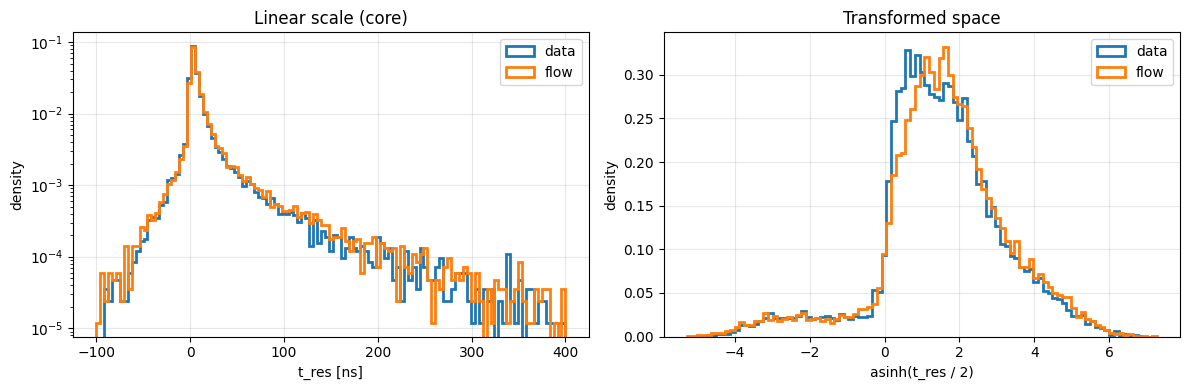

KS(data, flow) on t_res: 0.0513


In [25]:
t_samp = flow.sample_time_residual(ctx_t, n_steps=256).cpu().numpy().astype(np.float64)

def summarise(name, a):
    print(f'{name:5s} p1={np.percentile(a,1):9.2f} p25={np.percentile(a,25):8.2f} '
          f'median={np.median(a):8.2f} p75={np.percentile(a,75):8.2f} '
          f'p99={np.percentile(a,99):9.2f} frac<0={np.mean(a<0):.4f} max={a.max():.0f}')
summarise('data', t_np); summarise('flow', t_samp)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
b = np.linspace(-100, 400, 120)
ax[0].hist(t_np, bins=b, histtype='step', lw=2, density=True, label='data')
ax[0].hist(t_samp, bins=b, histtype='step', lw=2, density=True, label='flow')
ax[0].set_xlabel('t_res [ns]'); ax[0].set_ylabel('density'); ax[0].set_yscale('log')
ax[0].legend(); ax[0].grid(alpha=.3); ax[0].set_title('Linear scale (core)')

# in transformed space, where the flow actually works
w_d = flow.transform_time(torch.from_numpy(t_np)).numpy()
w_f = flow.transform_time(torch.from_numpy(t_samp)).numpy()
b2 = np.linspace(min(w_d.min(), w_f.min()), max(w_d.max(), w_f.max()), 100)
ax[1].hist(w_d, bins=b2, histtype='step', lw=2, density=True, label='data')
ax[1].hist(w_f, bins=b2, histtype='step', lw=2, density=True, label='flow')
ax[1].set_xlabel(f'{flow.time_transform}(t_res / {flow.time_scale:g})')
ax[1].set_ylabel('density'); ax[1].legend(); ax[1].grid(alpha=.3)
ax[1].set_title('Transformed space')
plt.tight_layout(); plt.show()
print('KS(data, flow) on t_res:', stats.ks_2samp(t_np, t_samp).statistic.round(4))

### B5 — calibration (PIT)

`t_res` is continuous, so the ordinary PIT applies directly: `F(t_res | c)` should be
`Uniform(0,1)`. `cdf_time_residual` is exact — the 1-D flow map and the transform are
both monotone, so the CDF is the base-space Gaussian CDF of the transported point.

- **U-shaped** -> too narrow  - **∩-shaped** -> too wide  - **sloped** -> biased

PIT mean = 0.4571 (want 0.5), std = 0.2944 (want 0.2887)
KS vs Uniform(0,1): stat = 0.0655, p = 4.91e-75


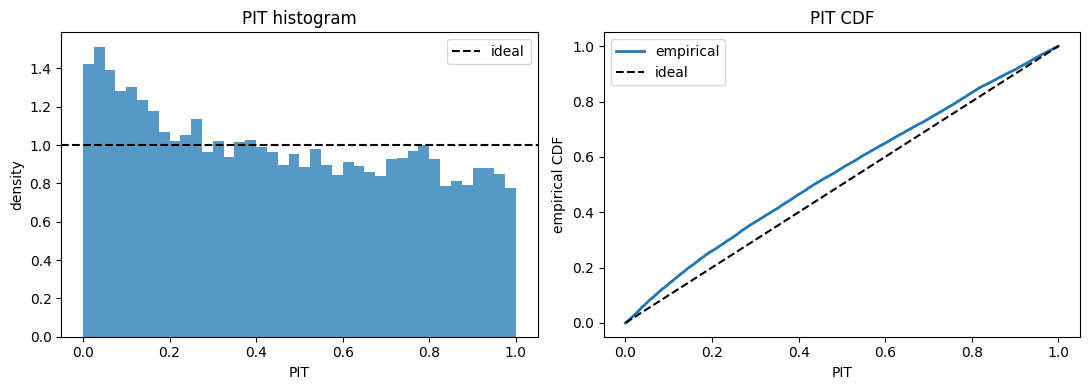


calibration split by t_res regime:
       t_res range       n  PIT mean       KS          p
[-1000000000,       0)    1967    0.2549   0.3537  1.22e-220
[       0,      10)   12560    0.3917   0.1549  1.62e-263
[      10,      50)    4026    0.6383   0.2134  2.22e-161
[      50,     200)    1218    0.7756   0.4066  1.86e-182
[     200,1000000000)     229    0.9028   0.6631   1.63e-99


In [26]:
pit = flow.cdf_time_residual(t_true.to(device), ctx_t, n_steps=N_STEPS).cpu().numpy()
ks = stats.kstest(pit, 'uniform')
print(f'PIT mean = {pit.mean():.4f} (want 0.5), std = {pit.std():.4f} '
      f'(want {1/np.sqrt(12):.4f})')
print(f'KS vs Uniform(0,1): stat = {ks.statistic:.4f}, p = {ks.pvalue:.3g}')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(pit, bins=40, density=True, alpha=.75)
ax[0].axhline(1.0, color='k', ls='--', label='ideal')
ax[0].set_xlabel('PIT'); ax[0].set_ylabel('density'); ax[0].set_title('PIT histogram')
ax[0].legend()
ax[1].plot(np.sort(pit), np.linspace(0, 1, len(pit)), lw=2, label='empirical')
ax[1].plot([0, 1], [0, 1], 'k--', label='ideal')
ax[1].set_xlabel('PIT'); ax[1].set_ylabel('empirical CDF'); ax[1].legend()
ax[1].set_title('PIT CDF')
plt.tight_layout(); plt.show()

print('\ncalibration split by t_res regime:')
print(f'{"t_res range":>18} {"n":>7} {"PIT mean":>9} {"KS":>8} {"p":>10}')
for lo, hi in [(-1e9, 0), (0, 10), (10, 50), (50, 200), (200, 1e9)]:
    m = (t_np >= lo) & (t_np < hi)
    if m.sum() < 50:
        continue
    k = stats.kstest(pit[m], 'uniform')
    print(f'[{lo:>8.0f},{hi:>8.0f}) {m.sum():>7d} {pit[m].mean():>9.4f} '
          f'{k.statistic:>8.4f} {k.pvalue:>10.2e}')

overall:  data PIT mean = 0.4535   null PIT mean = 0.4983   (null != 0.5 is pure ODE error)
per-bin standard error on a mean = 0.0050

perp distance [m]
                   range       n  PIT data  PIT null  KS data
  [     0.01,     2.39)    3333    0.4038    0.4968   0.1467
  [     2.39,     5.48)    3334    0.4180    0.5026   0.1372
  [     5.48,     8.99)    3333    0.4287    0.5018   0.1269
  [     8.99,    14.36)    3333    0.4814    0.4951   0.0403
  [    14.36,    24.06)    3333    0.4844    0.4932   0.0299
  [    24.06,   162.81)    3334    0.5049    0.5006   0.0192
log10(E / GeV)
                   range       n  PIT data  PIT null  KS data
  [     2.00,     3.90)    3334    0.5454    0.5004   0.0660
  [     3.90,     4.78)    3333    0.4794    0.4985   0.0424
  [     4.78,     5.24)    3333    0.5004    0.4974   0.0306
  [     5.24,     5.59)    3297    0.4193    0.5018   0.1380
  [     5.59,     5.81)    3350    0.4017    0.4927   0.1492
  [     5.81,     6.00)    3353    0.

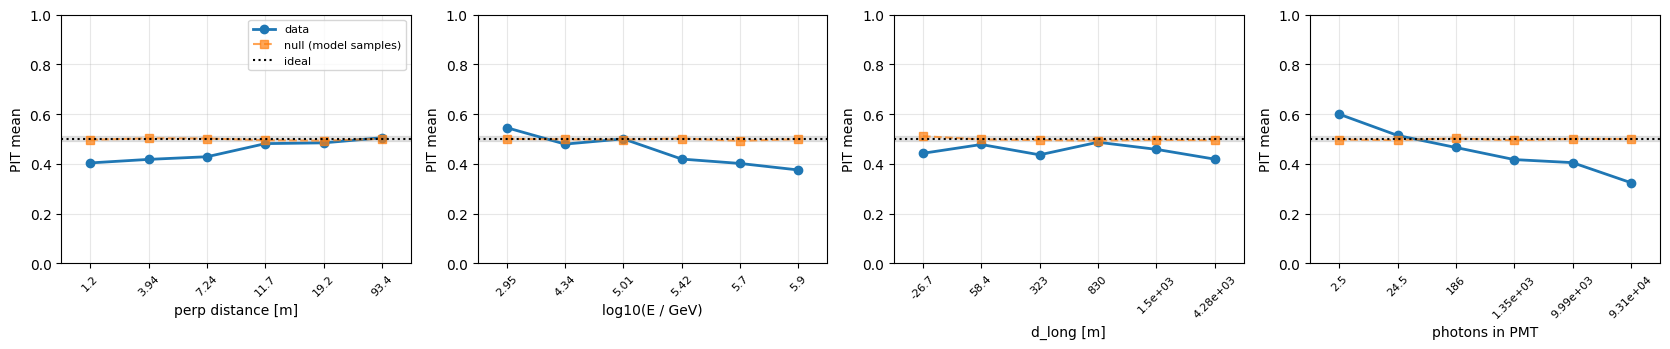

In [27]:
# --- B5b: PIT split by context, with a self-consistency null -----------------
# Splitting PIT by the OBSERVED t_res is circular (a perfect model reproduces the
# same trend). Uniformity must hold within any subset defined by c alone, so split
# on context variables instead.
PIT_STEPS = 256   # above N_STEPS: keeps ODE integration error out of the answer

# get_batch discards the row indices, so redo the draw keeping them
ph_s, rows_s = ds_t._sample_photons(N_EVAL_T)
pts_s  = torch.from_numpy(ds_t._point[rows_s])
vert_s = torch.from_numpy(ds_t._muon_pos[rows_s])
zen_s  = torch.from_numpy(ds_t._zenith[rows_s])
azi_s  = torch.from_numpy(ds_t._azimuth[rows_s])
ctx_s  = flow.build_context(pts_s, vert_s, torch.from_numpy(ds_t._energy[rows_s]),
                            zen_s, azi_s,
                            torch.from_numpy(ds_t._pmt_direction[rows_s])).to(device)
t_obs_s = flow.time_residual(torch.from_numpy(ds_t._t_hit[ph_s]), pts_s, vert_s,
                             zeniths=zen_s, azimuths=azi_s)

# context variables -- functions of c only, never of the observed time
zz = ds_t._zenith[rows_s].astype(np.float64)
aa = ds_t._azimuth[rows_s].astype(np.float64)
d_arr = np.stack([np.sin(zz)*np.cos(aa), np.sin(zz)*np.sin(aa), np.cos(zz)], 1)
u_trk = -d_arr if flow.track_dir_is_arrival else d_arr
rel_s = (ds_t._point[rows_s].astype(np.float64)
         - ds_t._muon_pos[rows_s].astype(np.float64))
d_long_s = (rel_s * u_trk).sum(1)
d_perp_s = np.linalg.norm(rel_s - d_long_s[:, None] * u_trk, axis=1)

# PIT of the data, and of times drawn from the model itself (the null)
pit_d = flow.cdf_time_residual(t_obs_s.to(device), ctx_s, n_steps=PIT_STEPS).cpu().numpy()
t_null = flow.sample_time_residual(ctx_s, n_steps=PIT_STEPS)
pit_n = flow.cdf_time_residual(t_null, ctx_s, n_steps=PIT_STEPS).cpu().numpy()

se = np.sqrt(1/12 / (N_EVAL_T / 6))
print(f'overall:  data PIT mean = {pit_d.mean():.4f}   '
      f'null PIT mean = {pit_n.mean():.4f}   (null != 0.5 is pure ODE error)')
print(f'per-bin standard error on a mean = {se:.4f}\n')

splits = [
    ('perp distance [m]',     d_perp_s),
    ('log10(E / GeV)',        np.log10(ds_t._energy[rows_s].astype(np.float64))),
    ('d_long [m]',            d_long_s),
    ('photons in PMT',        ds_t._photons_per_row[rows_s].astype(np.float64)),
]

fig, axes = plt.subplots(1, len(splits), figsize=(4.2*len(splits), 3.6))
for ax, (name, v) in zip(axes, splits):
    edges = np.unique(np.quantile(v, np.linspace(0, 1, 7)))
    print(f'{name}')
    print(f'  {"range":>22} {"n":>7} {"PIT data":>9} {"PIT null":>9} {"KS data":>8}')
    md, mn, lab = [], [], []
    for j in range(len(edges) - 1):
        m = (v >= edges[j]) & (v < edges[j+1] if j < len(edges)-2 else v <= edges[j+1])
        if m.sum() < 100:
            continue
        k = stats.kstest(pit_d[m], 'uniform')
        print(f'  [{edges[j]:>9.2f},{edges[j+1]:>9.2f}) {m.sum():>7d} '
              f'{pit_d[m].mean():>9.4f} {pit_n[m].mean():>9.4f} {k.statistic:>8.4f}')
        md.append(pit_d[m].mean()); mn.append(pit_n[m].mean())
        lab.append(f'{0.5*(edges[j]+edges[j+1]):.3g}')
    x = np.arange(len(md))
    ax.plot(x, md, 'o-', lw=2, label='data')
    ax.plot(x, mn, 's--', lw=1.5, alpha=.7, label='null (model samples)')
    ax.axhline(0.5, color='k', ls=':', label='ideal')
    ax.fill_between([-.5, len(md)-.5], .5-2*se, .5+2*se, color='k', alpha=.1)
    ax.set_xticks(x); ax.set_xticklabels(lab, rotation=45, fontsize=8)
    ax.set_xlim(-.5, len(md)-.5); ax.set_ylim(0, 1)
    ax.set_xlabel(name); ax.set_ylabel('PIT mean'); ax.grid(alpha=.3)
axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

### B6 — one PMT's conditional arrival-time density

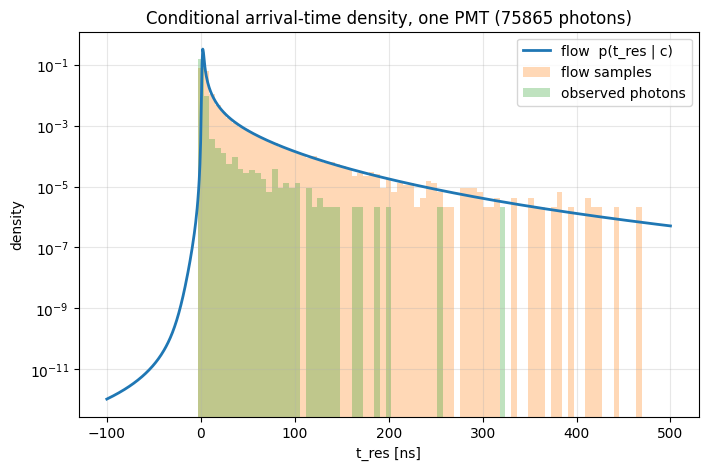

integral of the plotted density = 1.0055 (<1 if the grid truncates the tail)


In [30]:
test_row_photons = 0
photon_thres = 10000
while test_row_photons < photon_thres:
    i = np.random.randint(0, len(ds_t._photons_per_row))
    test_row_photons = ds_t._photons_per_row[i]
# i = int(np.argmax(ds_t._photons_per_row > 20)) if (ds_t._photons_per_row > 20).any() else 0
rows_i = np.array([i])
start = ds_t._row_photon_start[i]
n_ph = ds_t._photons_per_row[i]
t_obs = ds_t._t_hit[start:start + n_ph]

c1 = flow.build_context(
    torch.from_numpy(ds_t._point[rows_i]), torch.from_numpy(ds_t._muon_pos[rows_i]),
    torch.from_numpy(ds_t._energy[rows_i]), torch.from_numpy(ds_t._zenith[rows_i]),
    torch.from_numpy(ds_t._azimuth[rows_i]),
    torch.from_numpy(ds_t._pmt_direction[rows_i])).to(device)
res_obs = flow.time_residual(
    torch.from_numpy(t_obs), torch.from_numpy(np.tile(ds_t._point[i], (n_ph, 1))),
    torch.from_numpy(np.tile(ds_t._muon_pos[i], (n_ph, 1))),
    zeniths=torch.from_numpy(np.full(n_ph, ds_t._zenith[i])),
    azimuths=torch.from_numpy(np.full(n_ph, ds_t._azimuth[i]))).numpy()

grid = torch.linspace(-100, 500, 800, device=device, dtype=flow.param_dtype)
lp = flow.log_prob_time_residual(grid, c1.repeat(len(grid), 1), n_steps=256)
dens = lp.exp().cpu().numpy()
samp = flow.sample_time_residual(c1.repeat(len(res_obs), 1), n_steps=256).cpu().numpy()

plt.figure(figsize=(8, 5))
plt.plot(grid.cpu().numpy(), dens, lw=2, label='flow  p(t_res | c)')
plt.hist(samp, bins=np.linspace(-100, 500, 100), density=True, alpha=.3,
         label='flow samples')
# for k, r in enumerate(res_obs):
#     plt.axvline(r, color='red', alpha=.5, lw=1,
#                 label='observed photons' if k == 0 else None)
plt.hist(res_obs, bins=np.linspace(-100, 500, 100), density=True, alpha=.3,
         label='observed photons')
plt.xlabel('t_res [ns]'); plt.ylabel('density'); plt.yscale('log')
plt.legend(); plt.grid(alpha=.3)
plt.title(f'Conditional arrival-time density, one PMT ({n_ph} photons)')
plt.show()
print('integral of the plotted density =',
      round(float(np.trapezoid(dens, grid.cpu().numpy())), 4),
      '(<1 if the grid truncates the tail)')

### B7 — conditional trends

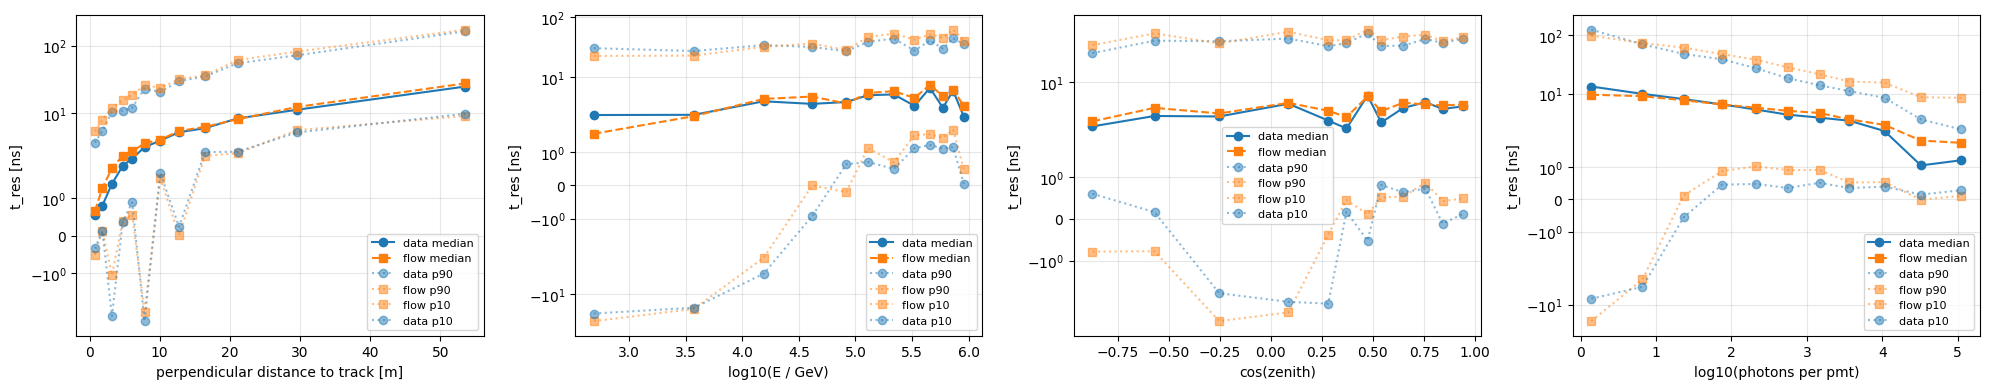

In [32]:
ph, rws = ds_t._sample_photons(N_EVAL_T)
pts, vert = ds_t._point[rws], ds_t._muon_pos[rws]
zz, aa = ds_t._zenith[rws], ds_t._azimuth[rws]
uu = -np.stack([np.sin(zz)*np.cos(aa), np.sin(zz)*np.sin(aa), np.cos(zz)], 1)
relv = pts - vert
counts = ds_t._photons_per_row[rws]
al = (relv*uu).sum(1)
pp = np.linalg.norm(relv - al[:, None]*uu, axis=1)

ctx_s = flow.build_context(
    torch.from_numpy(pts), torch.from_numpy(vert),
    torch.from_numpy(ds_t._energy[rws]), torch.from_numpy(zz),
    torch.from_numpy(aa), torch.from_numpy(ds_t._pmt_direction[rws])).to(device)
t_d = flow.time_residual(torch.from_numpy(ds_t._t_hit[ph]), torch.from_numpy(pts),
                         torch.from_numpy(vert), zeniths=torch.from_numpy(zz),
                         azimuths=torch.from_numpy(aa)).numpy()
t_m = flow.sample_time_residual(ctx_s, n_steps=256).cpu().numpy()

fig, ax = plt.subplots(1, 4, figsize=(20, 4))
for a, x, lab in [(ax[0], pp, 'perpendicular distance to track [m]'),
                  (ax[1], np.log10(ds_t._energy[rws]), 'log10(E / GeV)'),
                  (ax[2], np.cos(zz), 'cos(zenith)'),
                  (ax[3], np.log10(counts), 'log10(photons per pmt)')
                  ]:
    qs = np.quantile(x, np.linspace(0, 1, 13))
    idx = np.digitize(x, qs[1:-1])
    cx, dmed, mmed, dhi, mhi, mlow, dlow = [], [], [], [], [], [], []
    for b in range(12):
        m = idx == b
        if m.sum() < 50:
            continue
        cx.append(x[m].mean())
        dmed.append(np.median(t_d[m])); mmed.append(np.median(t_m[m]))
        dhi.append(np.percentile(t_d[m], 90)); mhi.append(np.percentile(t_m[m], 90))
        mlow.append(np.percentile(t_m[m], 10))
        dlow.append(np.percentile(t_d[m], 10))
    a.plot(cx, dmed, 'o-', color='C0', label='data median')
    a.plot(cx, mmed, 's--', color='C1', label='flow median')
    a.plot(cx, dhi, 'o:', color='C0', alpha=.5, label='data p90')
    a.plot(cx, mhi, 's:', color='C1', alpha=.5, label='flow p90')
    a.plot(cx, mlow, 's:', color='C1', alpha=.5, label='flow p10')
    a.plot(cx, dlow, 'o:', color='C0', alpha=.5, label='data p10')
    a.set_xlabel(lab); a.set_ylabel('t_res [ns]'); a.set_yscale('symlog')
    a.legend(fontsize=8); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

### B8 — joint distribution of per-PMT timing summaries

One point per PMT: the median (and IQR) of `t_res` taken over the *same number* of
photons for data and flow, so both carry identical sampling noise and can be compared
directly.

The context columns are shared by construction — both sets use the same rows — so those
panels **must** overlap exactly. They are a control on the pairing, not a test. All the
information is in the `median t_res` row: does the flow place the arrival-time peak
correctly, and give it the right width, as a function of context?

`'log10(IQR t_res + 1)'` and `'d_long [m]'` are also available for `CORNER_VARS_T`.
Swapping the median for the IQR is the sharper test of whether the flow is hedging by
broadening the direct peak.

10,000 PMTs, 189,510 photons (32 max per PMT)
  data  median-of-medians +2.034  IQR-of-medians 1.534  median log10(IQR+1) 0.566
  flow  median-of-medians +1.817  IQR-of-medians 1.464  median log10(IQR+1) 0.940


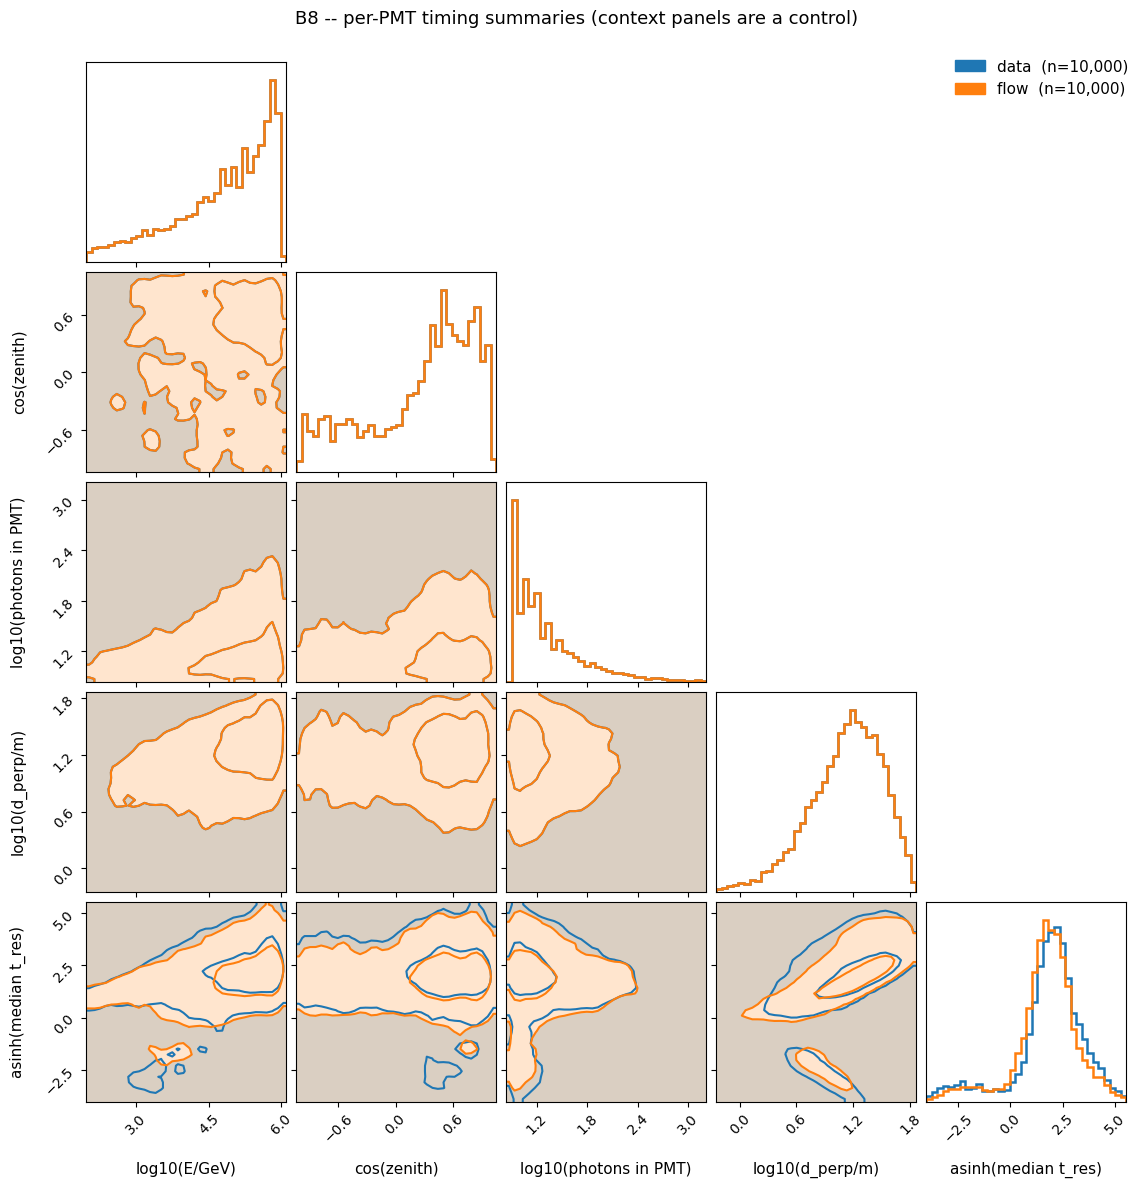

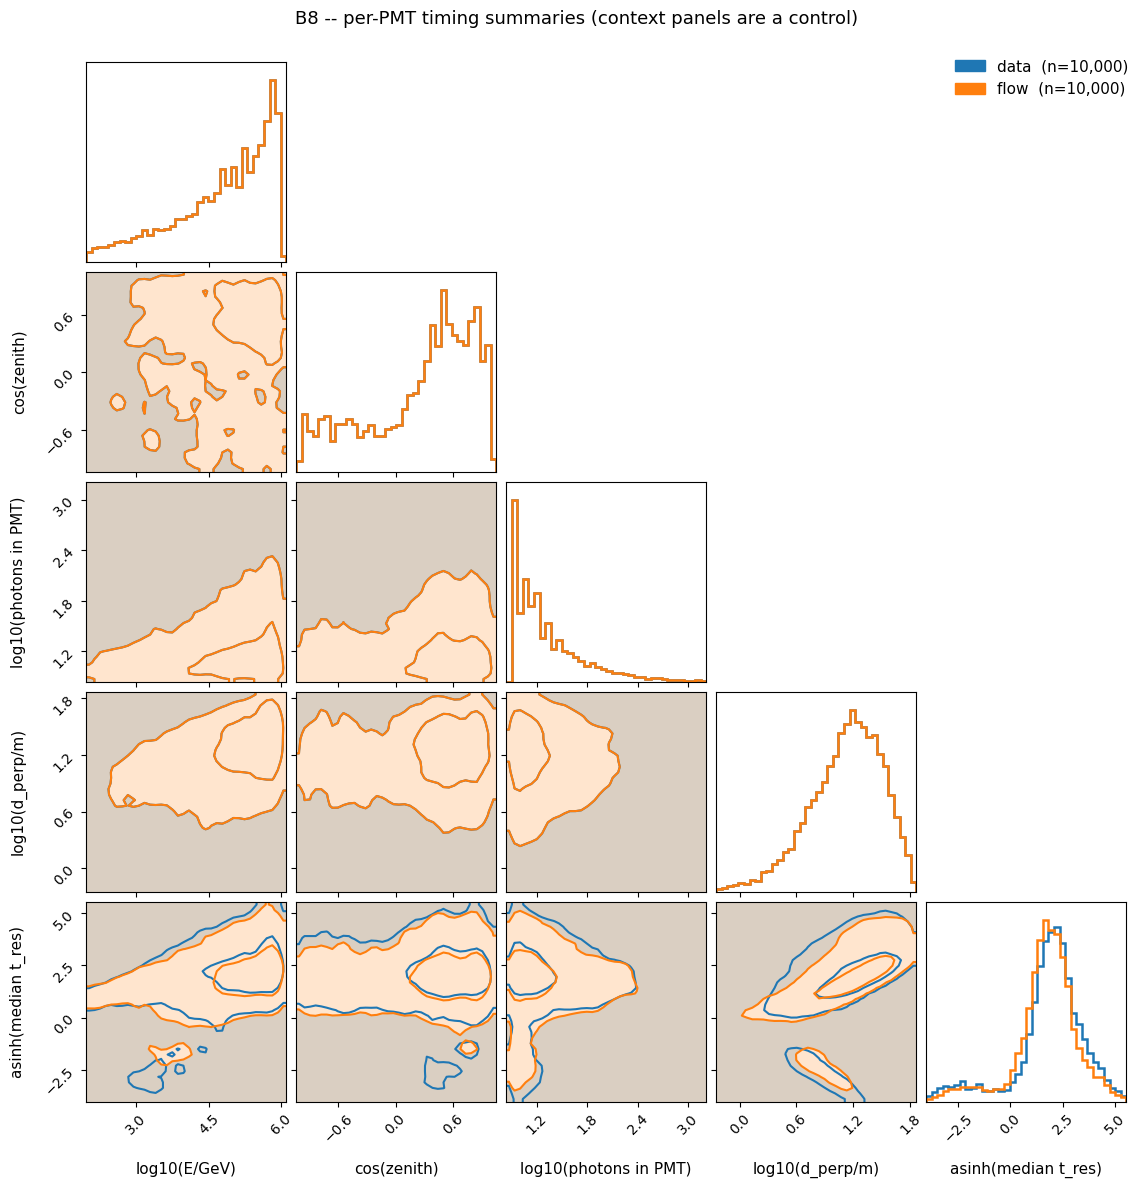

In [ ]:
# --- B8 -- joint distribution of per-PMT timing summaries, data vs flow ------
# One point per PMT. The context columns are shared by construction (same rows),
# so those panels must overlap exactly -- they are a control. The information is
# in the median/IQR row: does the flow put the arrival-time peak in the right
# place, and give it the right width, as a function of context?
MIN_PH_CORNER = 8         # need enough photons for a stable median
CAP_PH        = 32        # photons per PMT used, same count for data and sim
N_CORNER_ROWS = 10000
CORNER_STEPS  = 64

CORNER_VARS_T = ['log10(E/GeV)', 'cos(zenith)', 'log10(photons in PMT)',
                 'log10(d_perp/m)', f'{flow.time_transform}(median t_res)']

rng_c = np.random.default_rng(0)
cand = np.flatnonzero(ds_t._photons_per_row >= MIN_PH_CORNER)
sel = rng_c.choice(cand, size=min(N_CORNER_ROWS, len(cand)), replace=False)
use = np.minimum(ds_t._photons_per_row[sel], CAP_PH).astype(np.int64)

# random (not leading) photons per row -- the stored times may be time-ordered
ph_idx = np.concatenate([
    ds_t._row_photon_start[r] + rng_c.permutation(ds_t._photons_per_row[r])[:u]
    for r, u in zip(sel, use)])
rows_rep = np.repeat(sel, use)

pts_r = torch.from_numpy(ds_t._point[rows_rep])
vrt_r = torch.from_numpy(ds_t._muon_pos[rows_rep])
zen_r = torch.from_numpy(ds_t._zenith[rows_rep])
azi_r = torch.from_numpy(ds_t._azimuth[rows_rep])

t_dat = flow.time_residual(torch.from_numpy(ds_t._t_hit[ph_idx]), pts_r, vrt_r,
                           zeniths=zen_r, azimuths=azi_r).numpy().astype(np.float64)

ctx_r = flow.build_context(pts_r, vrt_r, torch.from_numpy(ds_t._energy[rows_rep]),
                           zen_r, azi_r,
                           torch.from_numpy(ds_t._pmt_direction[rows_rep])).to(device)
t_sim = flow.sample_time_residual(ctx_r, n_steps=CORNER_STEPS).cpu().numpy().astype(np.float64)

bnd = np.concatenate([[0], np.cumsum(use)])
seg = lambda a, f: np.array([f(a[bnd[i]:bnd[i + 1]]) for i in range(len(sel))])
iqr = lambda a: np.percentile(a, 75) - np.percentile(a, 25)
tf = lambda m: flow.transform_time(torch.from_numpy(np.asarray(m))).numpy()

zz, aa = ds_t._zenith[sel].astype(np.float64), ds_t._azimuth[sel].astype(np.float64)
dvec = np.stack([np.sin(zz) * np.cos(aa), np.sin(zz) * np.sin(aa), np.cos(zz)], 1)
u_t = -dvec if flow.track_dir_is_arrival else dvec
rel = ds_t._point[sel].astype(np.float64) - ds_t._muon_pos[sel].astype(np.float64)
dl_t = (rel * u_t).sum(1)
dp_t = np.linalg.norm(rel - dl_t[:, None] * u_t, axis=1)

ctx_cols = {
    'log10(E/GeV)':          np.log10(np.maximum(ds_t._energy[sel], 1e-12)),
    'cos(zenith)':           np.cos(zz),
    'azimuth':               aa,
    'log10(photons in PMT)': np.log10(ds_t._photons_per_row[sel]),
    'log10(d_perp/m)':       np.log10(np.maximum(dp_t, 1e-2)),
    'd_long [m]':            dl_t,
}
S_data = {**ctx_cols,
          f'{flow.time_transform}(median t_res)': tf(seg(t_dat, np.median)),
          'log10(IQR t_res + 1)': np.log10(seg(t_dat, iqr) + 1)}
S_flow = {**ctx_cols,
          f'{flow.time_transform}(median t_res)': tf(seg(t_sim, np.median)),
          'log10(IQR t_res + 1)': np.log10(seg(t_sim, iqr) + 1)}

print(f'{len(sel):,} PMTs, {use.sum():,} photons ({CAP_PH} max per PMT)')
for nm, S in [('data', S_data), ('flow', S_flow)]:
    k = f'{flow.time_transform}(median t_res)'
    print(f'  {nm:4s}  median-of-medians {np.median(S[k]):+.3f}  '
          f'IQR-of-medians {np.percentile(S[k],75)-np.percentile(S[k],25):.3f}  '
          f'median log10(IQR+1) {np.median(S["log10(IQR t_res + 1)"]):.3f}')

nugget.utils.vis_tools.plot_corner_compare(
    {'data': S_data, 'flow': S_flow}, variables=CORNER_VARS_T,
    bins=36, smooth=1.0,
    title='B8 -- per-PMT timing summaries (context panels are a control)')

---
# Part C — all three models together

Simulate a whole event end to end:

1. **`HitClassifier`** over the *entire geometry* -> which PMTs fire,
2. **`FlowMatchLY`** at each fired PMT -> how many photons `q`,
3. **`FlowMatchATime`** -> `q` arrival times at that PMT.

That is the complete hurdle factorisation,
`p(q, t | c) = pi(c) . p_LY(q | c, q>=1) . prod_j p_T(t_j | c)`.

Handily, the arrival-time parquet gives the *data* light yield for free: the number of
entries in a PMT's `times` list **is** its photon count, so the real and simulated
sides are directly comparable without touching a second file.

Part A checks `pi(c)` alone and Part B checks `p(t|c)` on PMTs already known to be hit;
only here do the error modes compound the way they will in real use.

In [55]:
# a real event, from the arrival-time test set
rng2 = np.random.default_rng()
for _ in range(50000):
    evc = int(rng2.choice(ds_t._events))
    rows_ev = ds_t._event_rows[evc]
    if len(rows_ev) >= 5000:
        break
r0 = rows_ev[0]
print(f'event {evc}: {len(rows_ev)} hit PMTs, E={ds_t._energy[r0]:.3g} GeV, '
      f'zenith={ds_t._zenith[r0]:.3f}')

# --- classifier over the whole geometry at this event's parameters ---
geo_all = pd.read_csv(GEOM, usecols=['om_x','om_y','om_z',
                                     'pmt_dir_x','pmt_dir_y','pmt_dir_z'])
G_pos = geo_all[['om_x','om_y','om_z']].to_numpy(np.float32)
G_dir = geo_all[['pmt_dir_x','pmt_dir_y','pmt_dir_z']].to_numpy(np.float32)
NG = len(G_pos)

p_all = np.empty(NG, np.float64)
B = 65536
for s in range(0, NG, B):
    e = min(s + B, NG)
    b = e - s
    c = hit.build_context(
        torch.from_numpy(G_pos[s:e]),
        torch.from_numpy(np.tile(ds_t._muon_pos[r0], (b, 1))),
        torch.from_numpy(np.full(b, ds_t._energy[r0], np.float32)),
        torch.from_numpy(np.full(b, ds_t._zenith[r0], np.float32)),
        torch.from_numpy(np.full(b, ds_t._azimuth[r0], np.float32)),
        torch.from_numpy(G_dir[s:e])).to(device)
    p_all[s:e] = hit.predict_hit_prob(c, calibrated=True).detach().cpu().numpy()

fired = rng2.random(NG) < p_all
print(f'classifier: expected {p_all.sum():.1f} hits, sampled {fired.sum()}, '
      f'data has {len(rows_ev)}')

event 5206: 6767 hit PMTs, E=9.08e+05 GeV, zenith=0.721
classifier: expected 3915.8 hits, sampled 3803, data has 6767


In [56]:
# --- step 2: light yield at each fired PMT, from the LY flow ---
N_STEPS = 256
idx_f = np.flatnonzero(fired)
NF = len(idx_f)


def event_ctx(model, gidx):
    n = len(gidx)
    return model.build_context(
        torch.from_numpy(G_pos[gidx]),
        torch.from_numpy(np.tile(ds_t._muon_pos[r0], (n, 1))),
        torch.from_numpy(np.full(n, ds_t._energy[r0], np.float32)),
        torch.from_numpy(np.full(n, ds_t._zenith[r0], np.float32)),
        torch.from_numpy(np.full(n, ds_t._azimuth[r0], np.float32)),
        torch.from_numpy(G_dir[gidx])).to(device)


if NF:
    q_sim = ly.sample_light_yield(event_ctx(ly, idx_f), n_steps=N_STEPS,
                                  discrete=True).detach().cpu().numpy()
else:
    q_sim = np.array([])

# data side: photon count per hit PMT is just the length of its `times` list
q_real = ds_t._photons_per_row[rows_ev].astype(np.float64)
pos_real = ds_t._point[rows_ev]

print(f'hit PMTs      : sim {NF:5d}   data {len(rows_ev):5d}')
if NF:
    print(f'total photons : sim {q_sim.sum():8.0f}   data {q_real.sum():8.0f}')
    print(f'LY per PMT    : sim median {np.median(q_sim):5.1f} max {q_sim.max():7.0f} | '
          f'data median {np.median(q_real):5.1f} max {q_real.max():7.0f}')

hit PMTs      : sim  3803   data  6767
total photons : sim    95160   data   163754
LY per PMT    : sim median   2.0 max   15674 | data median   2.0 max    3131


In [57]:
# --- step 3: arrival times, q_i photons at each fired PMT ---
# The 3-D panel shows the EARLIEST photon per PMT, so cap the draws per PMT: the
# minimum of the first PHOTON_CAP samples is a fine estimator of the first hit and
# keeps a bright PMT (LY can reach 1e4+) from dominating the cost.
PHOTON_CAP = 64

# np.inf, not np.nan: np.minimum.at propagates NaN and would blank every entry
t_first_sim = np.full(NF, np.inf)
if NF:
    # n_draw = np.minimum(q_sim, PHOTON_CAP).astype(np.int64)
    # n_draw = np.maximum(n_draw, 1)
    n_draw = q_sim.astype(np.int64)
    rep = np.repeat(np.arange(NF), n_draw)
    gi_rep = idx_f[rep]
    ctx_rep = event_ctx(flow, gi_rep)
    t_all = flow.sample_arrival_time(
        ctx_rep, torch.from_numpy(G_pos[gi_rep]),
        torch.from_numpy(np.tile(ds_t._muon_pos[r0], (len(rep), 1))),
        zeniths=torch.from_numpy(np.full(len(rep), ds_t._zenith[r0], np.float32)),
        azimuths=torch.from_numpy(np.full(len(rep), ds_t._azimuth[r0], np.float32)),
        n_steps=N_STEPS).detach().cpu().numpy()
    np.minimum.at(t_first_sim, rep, t_all)   # earliest photon per PMT
    print(f'sampled {len(rep):,} photons across {NF} PMTs '
          f'(cap {PHOTON_CAP}/PMT)')

# data: earliest photon per hit PMT
t_first_real = np.array([
    ds_t._t_hit[ds_t._row_photon_start[r]:
                ds_t._row_photon_start[r] + ds_t._photons_per_row[r]].min()
    for r in rows_ev])

if NF:
    print(f'first-hit time: sim   p1={np.percentile(t_first_sim,1):8.0f} '
          f'median={np.median(t_first_sim):8.0f} p99={np.percentile(t_first_sim,99):8.0f}')
    print(f'                data  p1={np.percentile(t_first_real,1):8.0f} '
          f'median={np.median(t_first_real):8.0f} p99={np.percentile(t_first_real,99):8.0f}')

sampled 95,160 photons across 3803 PMTs (cap 64/PMT)
first-hit time: sim   p1=     147 median=    1750 p99=    4629
                data  p1=     170 median=    2401 p99=    4616


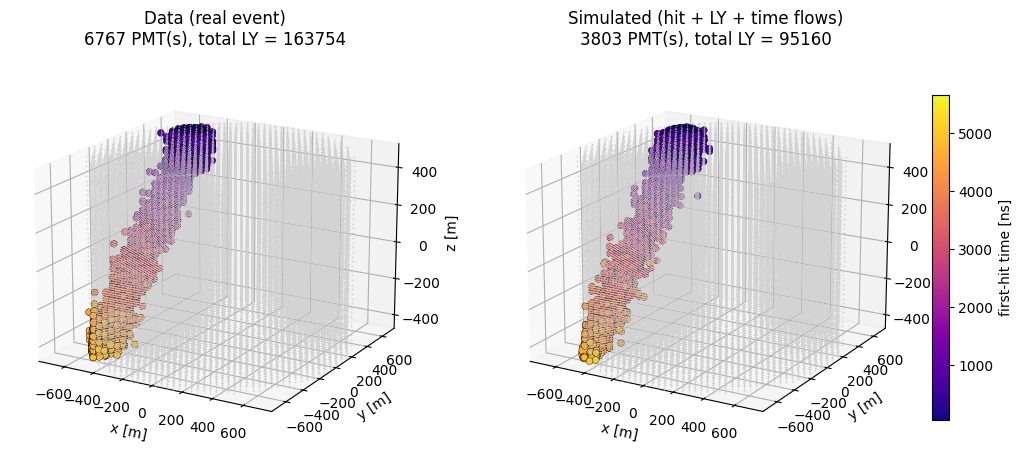

In [58]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib.colors import Normalize

# shared colour scale (first-hit time) and size scale (light yield, log)
tmin = min(t_first_real.min(), t_first_sim.min()) if NF else t_first_real.min()
tmax = max(t_first_real.max(), t_first_sim.max()) if NF else t_first_real.max()
norm = Normalize(vmin=tmin, vmax=tmax)
size_fn = lambda q: 8.0 + 55.0 * np.log10(q + 1.0)
lims = [(G_pos[:, k].min(), G_pos[:, k].max()) for k in range(3)]

fig = plt.figure(figsize=(14, 6.5))
panels = [('Data (real event)', pos_real, t_first_real, q_real),
          ('Simulated (hit + LY + time flows)', G_pos[idx_f], t_first_sim, q_sim)]
scs = []
for i, (title, xyz, tt, qq) in enumerate(panels):
    ax = fig.add_subplot(1, 2, i + 1, projection='3d')
    ax.scatter(G_pos[:, 0], G_pos[:, 1], G_pos[:, 2], s=1, c='lightgray',
               alpha=.05, linewidth=0, depthshade=False)
    if len(xyz):
        sc = ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], s=size_fn(qq), c=tt,
                        cmap='plasma', norm=norm, edgecolor='k', linewidth=.3,
                        depthshade=False)
        scs.append(sc)
    ax.set_xlim(*lims[0]); ax.set_ylim(*lims[1]); ax.set_zlim(*lims[2])
    ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]'); ax.set_zlabel('z [m]')
    ax.set_title(f'{title}\n{len(xyz)} PMT(s), total LY = {qq.sum():.0f}')
    ax.view_init(elev=18, azim=-60)
if scs:
    fig.colorbar(scs[0], ax=fig.get_axes(), shrink=.65, pad=.02,
                 label='first-hit time [ns]')
# plt.suptitle(f'Event {evc}: real vs. fully simulated event '
#              f'(size ~ light yield, colour = first-hit time)')
plt.show()

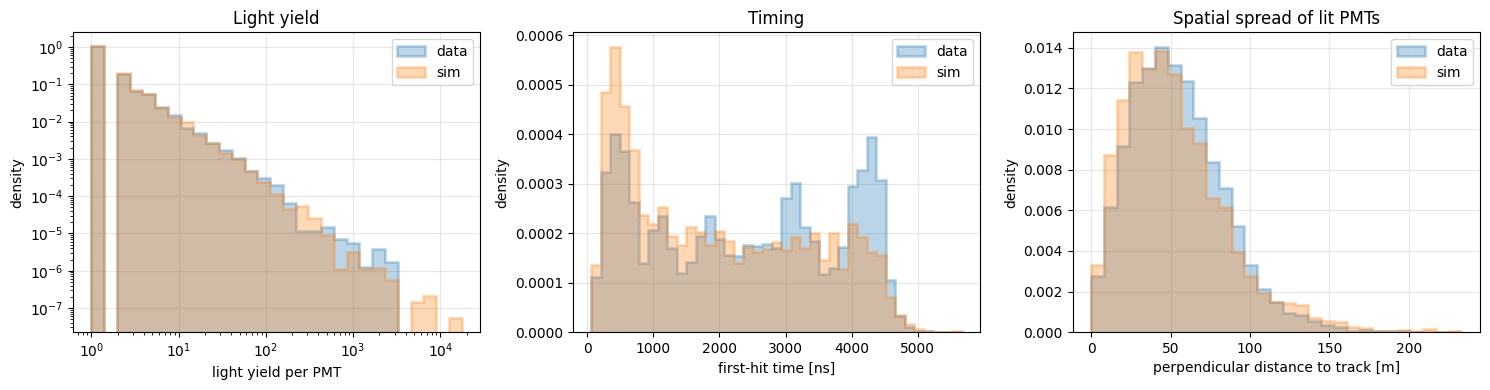

KS(data, sim)  light yield : 0.0153
KS(data, sim)  first time  : 0.1231
KS(data, sim)  perp dist   : 0.0606


In [59]:
# --- aggregate comparison of the simulated vs real event ---
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

if NF:
    b = np.logspace(0, np.log10(max(q_real.max(), q_sim.max())) + .05, 30)
    ax[0].hist(q_real, bins=b, histtype='step', lw=2, density=True, label='data', fill=True, alpha=.3)
    ax[0].hist(q_sim, bins=b, histtype='step', lw=2, density=True, label='sim', fill=True, alpha=.3)
    ax[0].set_xscale('log'); ax[0].set_yscale('log')
ax[0].set_xlabel('light yield per PMT'); ax[0].set_ylabel('density')
ax[0].set_title('Light yield'); ax[0].legend(); ax[0].grid(alpha=.3)

if NF:
    b = np.linspace(min(t_first_real.min(), t_first_sim.min()),
                    max(t_first_real.max(), t_first_sim.max()), 40)
    ax[1].hist(t_first_real, bins=b, histtype='step', lw=2, density=True, label='data', fill=True, alpha=.3)
    ax[1].hist(t_first_sim, bins=b, histtype='step', lw=2, density=True, label='sim', fill=True, alpha=.3)
ax[1].set_xlabel('first-hit time [ns]'); ax[1].set_ylabel('density')
ax[1].set_title('Timing'); ax[1].legend(); ax[1].grid(alpha=.3)

# radial profile: perpendicular distance of lit PMTs from the track
uev_ = -np.array([np.sin(ds_t._zenith[r0])*np.cos(ds_t._azimuth[r0]),
                  np.sin(ds_t._zenith[r0])*np.sin(ds_t._azimuth[r0]),
                  np.cos(ds_t._zenith[r0])])
def perp_of(xyz):
    rel = xyz - ds_t._muon_pos[r0]
    al = rel @ uev_
    return np.linalg.norm(rel - al[:, None]*uev_, axis=1)
pr_real, pr_sim = perp_of(pos_real), (perp_of(G_pos[idx_f]) if NF else np.array([]))
if NF:
    b = np.linspace(0, max(pr_real.max(), pr_sim.max()), 30)
    ax[2].hist(pr_real, bins=b, histtype='step', lw=2, density=True, label='data', fill=True, alpha=.3)
    ax[2].hist(pr_sim, bins=b, histtype='step', lw=2, density=True, label='sim', fill=True, alpha=.3)
ax[2].set_xlabel('perpendicular distance to track [m]'); ax[2].set_ylabel('density')
ax[2].set_title('Spatial spread of lit PMTs'); ax[2].legend(); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

if NF:
    print(f'KS(data, sim)  light yield : {stats.ks_2samp(q_real, q_sim).statistic:.4f}')
    print(f'KS(data, sim)  first time  : '
          f'{stats.ks_2samp(t_first_real, t_first_sim).statistic:.4f}')
    print(f'KS(data, sim)  perp dist   : {stats.ks_2samp(pr_real, pr_sim).statistic:.4f}')

## Summary checklist

**Part A — classifier**

| test | pass condition |
|---|---|
| A2 reliability | points on the diagonal, ECE small |
| A3 ROC / PR | AUC well above 0.5 |
| A4 prior correction | calibrated mean / true occupancy ≈ 1.0 |
| A5 trends | P(hit) falls with distance, rises with energy, tracking the data |
| A6 joint | data and classifier contours overlap; no excess reach in `d_perp` |

**Part B — arrival-time flow**

| test | pass condition |
|---|---|
| B2 normalisation | integrals within ~1% of 1.0 |
| B3 ODE steps | error falls monotonically, flat past the chosen `N_STEPS` |
| B4 marginal | distributions overlap in both linear and transformed space |
| B5 PIT | flat histogram, diagonal CDF, no regime badly skewed |
| B7 trends | median and p90 residual both track the data vs distance |
| B8 joint | `median t_res` contours overlap; context panels identical (control) |

**Part C — all three jointly**

| check | pass condition |
|---|---|
| hit count | simulated ≈ real number of lit PMTs |
| light yield | LY-per-PMT distributions overlap, small KS |
| timing | first-hit time distributions overlap |
| spatial | perpendicular-distance profile matches (hits hug the track) |

Because the three models multiply, Part C is where small individual biases compound:
an over-eager classifier plus an under-dispersed LY flow can look acceptable
separately and clearly wrong together. If Part C disagrees while A and B pass,
suspect the *interaction* — most often the classifier firing PMTs far from the track,
which the LY flow then has to assign light to.

A **flat B7 with a good B4** is the separate signature of a flow that learned the
marginal `p(t_res)` and ignored the conditioning — cross-check the PIT.